# **K-Nearest Neighbors (KNN)**

KNN (K-Nearest Neighbors) is one of the simplest machine learning algorithms.

To determine the class of a data, It works by:
- Looking at the **K closest data points**
- Letting them **"vote"**
- Assigning the majority label to the new point

<br>

**What is 'K' in K Nearest Neighbour?**

In the k-Nearest Neighbours algorithm k is just a number that tells the algorithm how many nearby points or neighbors to look at when it makes a decision.

<br>



## **How does KNN decide?**

**Steps:**
1. Measure distance between new point and all training points
2. Sort by smallest distance
3. Choose K closest
4. Majority vote = prediction





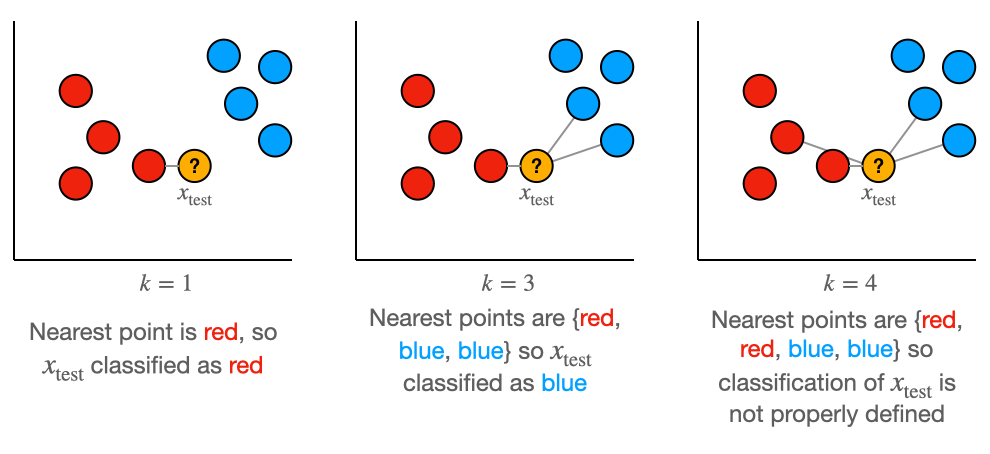

</br>

###**Problem:**
What if we tie?

</br>

####**Solution:**

- **Use odd K:** Choose an odd number for K (especially in binary classification) prevents ties from occurring in the first place.
- **Reduce K:** If a tie happens at a higher K value, decrease K by 1 until the tie is broken.

- **Randomly break the tie:**

- **Choose nearest (scikit-learn behavior)**: When two classes have equal votes, Scikit-learn automatically picks the class of the closest neighbor among them.

Note:
If distances are exactly identical, Scikit-learn returns whichever class appears first in the internal ordering — making results dependent on training data order in rare edge cases.

<br>

K-Nearest Neighbors is also called as a **lazy learner** algorithm because it does not learn from the training set immediately instead it stores the entire dataset and performs computations only at the time of classification.

<br>

##**Distance Metrics Used in KNN Algorithm**

KNN uses **distance metrics** to determine which data points are closest to each other.  
These distances define the "neighbors" that vote in classification or contribute to prediction in regression.

Choosing the right distance metric affects:
- Model behavior
- Decision boundaries
- Prediction accuracy

<br>

### **1. Euclidean Distance**

Euclidean distance is the **straight-line distance** between two points in space.  
It is what you naturally think of as distance in geometry.

> "How far would I walk if I went directly from point A to point B?"

**Formula:**
$d(x, x_i) = \sqrt{\sum_{j=1}^{d} (x_j - x_{ij})^2}$

Where:
- $ x $ = new point  
- $ x_i $ = existing point  
- $ d $ = number of features (dimensions)


    **Step-by-Step Example (2D):**

    Suppose we have:

    - Point A: $x = (2, 3)$  
    - Point B: $x_i = (5, 7)$

    1. Compute differences for each feature:

        $x_1 - x_{i1} = 2 - 5 = -3$  
        $x_2 - x_{i2} = 3 - 7 = -4$

    2. Square the differences:  $(-3)^2 = 9, \quad (-4)^2 = 16$

    3. Sum the squared differences:  $9 + 16 = 25$

    4. Take the square root:   $\sqrt{25} = 5$

    ✅ So the **Euclidean distance between A and B is 5**.  



<br>

### **2. Manhattan Distance**

Manhattan distance measures distance **only along grid paths**, like city streets.  
You can move horizontally and vertically — but not diagonally.

> Also known as *taxicab distance*.

**Formula:**

$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$

Where:
- $ n $ = number of features

    **Step-by-Step Example (2D):**

    Suppose we have:

    - Point A: $x = (2, 3)$  
    - Point B: $x_i = (5, 7)$

    1. Compute absolute differences for each feature:

        $|x_1 - y_1| = |2 - 5| = 3$  
        $|x_2 - y_2| = |3 - 7| = 4$

    2. Sum the absolute differences:  $3 + 4 = 7$


    ✅ So the **Manhattan distance between A and B is 7**.  


<br>

### **3. Minkowski Distance**

Minkowski distance is a **generalized formula** that includes multiple distance types.

**Formula:**

$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}$

<br>

**Special Cases:**
- When **p = 1** → Manhattan Distance  
- When **p = 2** → Euclidean Distance
- This makes Minkowski distance a **flexible distance metric** that adapts based on the value of \( p \).


    **Step-by-Step Example (2D):**

    Suppose we have:

    - Point A: $x = (2, 3)$  
    - Point B: $x_i = (5, 7)$

    1. Case 1: \( p = 1 \) (Manhattan distance): $d = |2-5| + |3-7| = 3 + 4 = 7$  
    

    2. Case 2: \( p = 2 \) (Euclidean distance): $d = \sqrt{(2-5)^2 + (3-7)^2} = \sqrt{9 + 16} = 5$

    3. Case 3: \( p = 3 \) (Minkowski with p=3): $d = \left(|2-5|^3 + |3-7|^3\right)^{1/3} = \left(27 + 64\right)^{1/3} \approx 4.02$


    ✅ So the **Manhattan distance between A and B is 7**.  


**Intuition**

- Minkowski distance allows you to **tune how the differences along features are combined**.
- Smaller \(p\) emphasizes **all dimensions equally** (like Manhattan).  
- Larger \(p\) emphasizes **larger differences more strongly** (like Euclidean and beyond).  
- In KNN, choosing different distance metrics can **affect which neighbors are "closest"**.



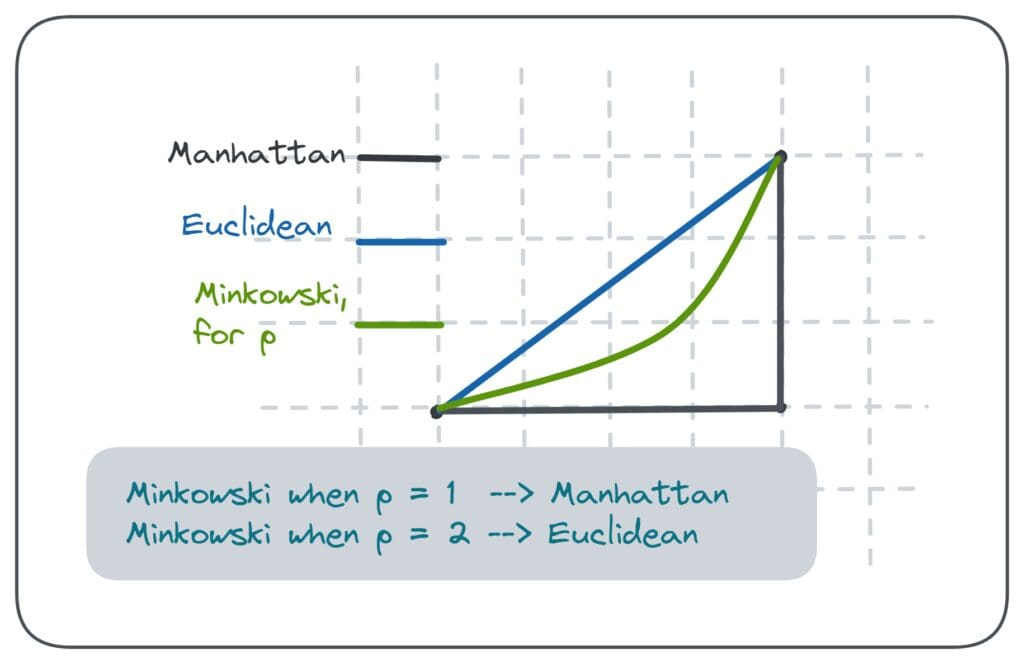

<br>

## ⚠️ Important Reminder

Since KNN relies on distance:
> **Feature scaling is mandatory** (e.g., standardization or normalization)

Without scaling, one feature can dominate the entire distance calculation.


<br><br>

# **KNN Implementation**


To understand KNN for classification, we'll work with a simple dataset representing gene expression levels. Gene expression levels are calculated by the ratio between the expression of the target gene (i.e., the gene of interest) and the expression of one or more reference genes (often household genes). This dataset is synthetic and specifically designed to show some of the strengths and limitations of using KNN for Classification.


More info on gene expression: https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/gene-expression-level

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/gene_expression.csv')
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

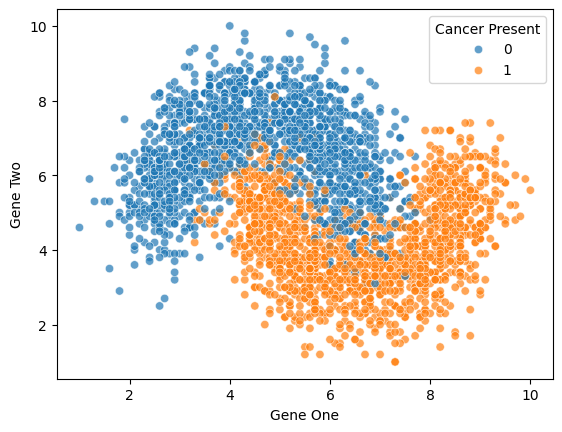

In [ ]:
sns.scatterplot(x='Gene One',y='Gene Two',hue='Cancer Present',data=df,alpha=0.7)

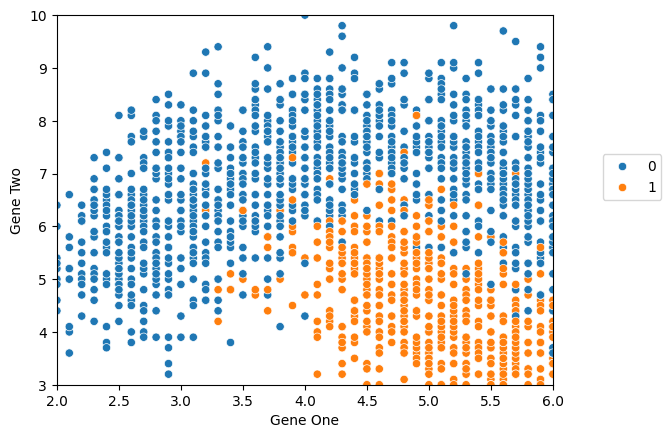

In [ ]:
sns.scatterplot(x='Gene One',y='Gene Two',hue='Cancer Present',data=df)
plt.xlim(2,6)
plt.ylim(3,10)
plt.legend(loc=(1.1,0.5))

### **Train|Test Split and Scaling Data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop('Cancer Present',axis=1)
y = df['Cancer Present']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn_model.fit(scaled_X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
full_test = pd.concat([X_test,y_test],axis=1)
len(full_test)

900

<Axes: xlabel='Gene One', ylabel='Gene Two'>

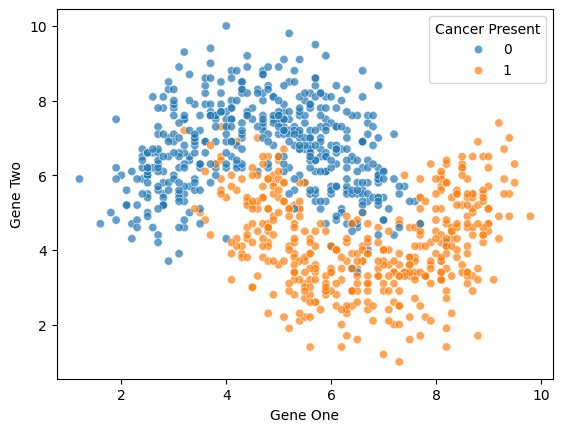

In [ ]:
sns.scatterplot(x='Gene One',y='Gene Two',hue='Cancer Present',
                data=full_test,alpha=0.7)

### **Model Evaluation**

In [ ]:
y_pred = knn_model.predict(scaled_X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

accuracy_score(y_test,y_pred)

0.8911111111111111

In [ ]:
confusion_matrix(y_test,y_pred)

array([[422,  48],
       [ 50, 380]])

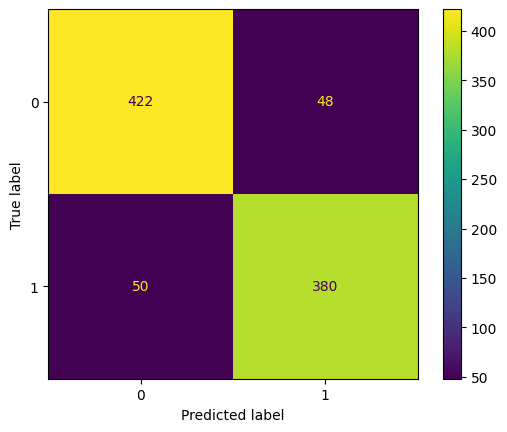

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create the ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       470
           1       0.89      0.88      0.89       430

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.89       900
weighted avg       0.89      0.89      0.89       900



<br><br>

## **How to select K?**

* **Elbow Method**
* **Cross-Validation**







<br>


### **Elbow Method:**

Draw a graph showing the error or accuracy for different k values. As k increases the error usually drops at first. But after a certain point error stops decreasing quickly. The point where the curve changes direction and looks like an "elbow" is usually the best choice for k.

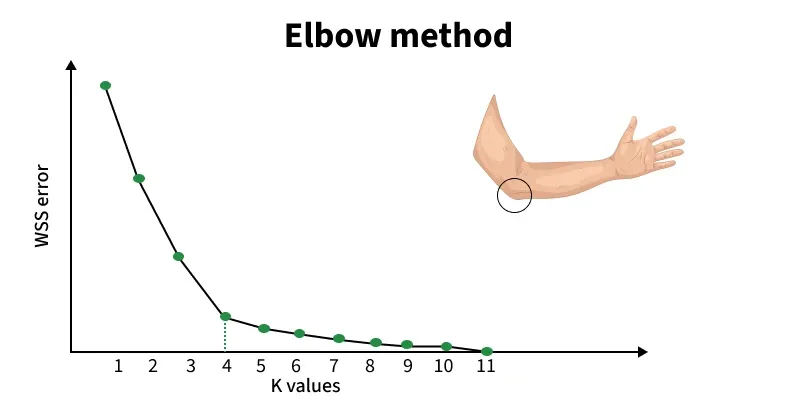

<br>

**NOTE: This uses the test set for the hyperparameter selection of K.**

In [ ]:
test_error_rates = []


for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train)

    y_pred_test = knn_model.predict(scaled_X_test)

    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

Text(0.5, 0, 'K Value')

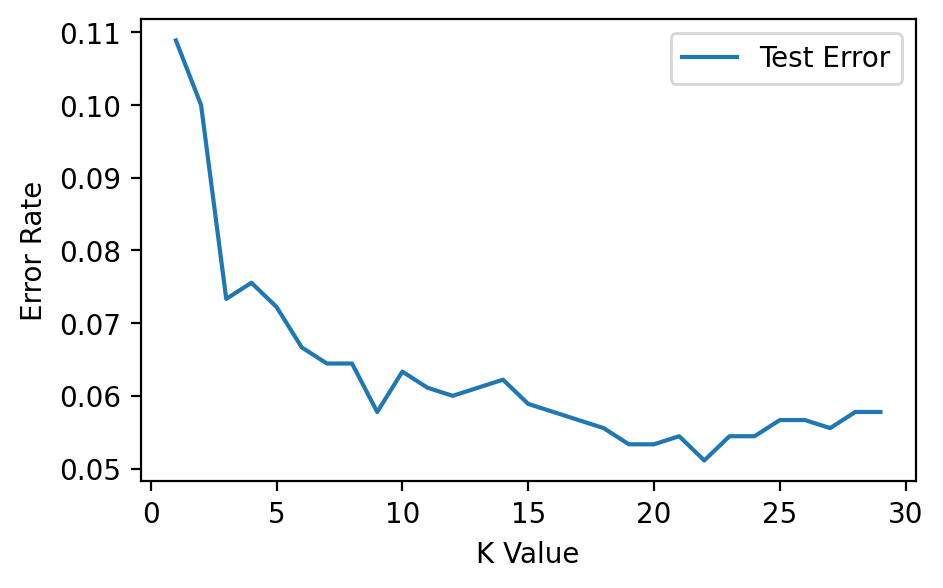

In [ ]:
plt.figure(figsize=(5,3),dpi=200)
plt.plot(range(1,30),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")

<br>

### **Cross-Validation:**

 Cross-validation is a **technique to evaluate how well a model generalizes** to unseen data.  It helps prevent overfitting and ensures that the model is reliable on new data.

  <br>

  **How K-Fold Cross-Validation Works**

  1. Split your dataset into **K equal folds** (parts).
  2. For each fold:
    - Use the fold as **validation set**.
    - Use the remaining K-1 folds as **training set**.
    - Train the model and evaluate on the validation set.
  3. Average the **performance metric** (accuracy, error, etc.) across all K folds.



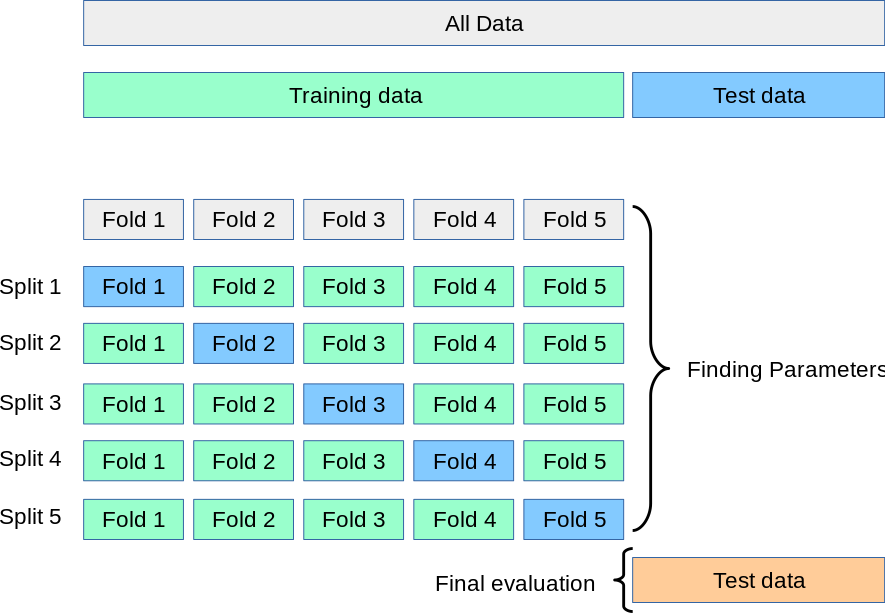

**Formula (Accuracy Example)**

$\text{CV Accuracy} = \frac{1}{K} \sum_{i=1}^{K} \text{Accuracy on fold i}$

$\text{CV Error} = 1 - \text{CV Accuracy}$

**Why Use Cross-Validation?**

- Using a single train/test split can give **biased results**.
- Cross-validation uses multiple splits to get a **more stable estimate of model performance**.
- Especially useful when tuning **hyperparameters**, e.g., `K` in KNN.

<br>

**Advantages of Cross-Validation**

- Reduces **variance** of model evaluation
- Uses **all data points** for training and validation
- Helps choose **hyperparameters** robustly (like K in KNN)

<br>

**Notes for KNN**

- KNN is sensitive to the **choice of K neighbors**.
- Using cross-validation:
  - Try multiple K values
  - Pick the K with **highest average accuracy** across folds
- Prevents overfitting that might occur if y


<br><br>

### **Grid Search for Hyperparameter Tuning**

Grid Search is a **systematic way to find the best hyperparameters** for a machine learning model.  
Instead of guessing, we evaluate all combinations of specified hyperparameter values.

<br>

**How Grid Search Works**

1. Define a **grid of hyperparameters** to search over.  
   Example for KNN:
   ```text
   n_neighbors = [1, 3, 5, 7, 9, 11]
   metric = ['euclidean', 'manhattan']

2. For each combination of hyperparameters:

    * Train the model
    * Evaluate performance (accuracy, error, etc.)

3. Select the **combination with the best performance**.


**How Grid Search Uses Cross-Validation:**

Grid Search usually uses **K-Fold Cross-Validation** internally.

For each hyperparameter combination:

1. Split data into **K folds**
2. Train on **K-1 folds**, validate on **1 fold**
3. Repeat **K times**
4. Average the **performance metric** across folds

> This ensures robust evaluation, not biased by a single train/test split.



⚠️ Note: Grid Search can be **computationally expensive** for many parameters.

<br><br>


### **Pipeline for Bundling Steps**

A **pipeline** in scikit-learn is a powerful tool that allows you to **chain multiple processing steps** together into a single, cohesive object.

Think of it as an assembly line for your data:

1.  **Preprocessing (e.g., Scaling):** Data enters the pipeline and is first transformed (e.g., scaled by `StandardScaler`).
2.  **Model Training (e.g., KNN):** The preprocessed data then moves to the next step, where a machine learning model (`KNeighborsClassifier` in this case) is trained.

<br>

#### **Why use Pipelines?**

-   **Convenience:** Simplifies your code by bundling all steps into one object.
-   **Data Leakage Prevention:** Crucially, pipelines prevent **data leakage**. When you use cross-validation within a pipeline, the preprocessing (like scaling) for each fold is applied *only* to the training data of that fold, and then the learned transformation is applied to the validation data. This ensures your model's performance estimate is unbiased.
-   **Reproducibility:** Makes your workflow more consistent and easier to reproduce.
-   **Grid Search Integration:** Pipelines integrate seamlessly with `GridSearchCV`, allowing you to tune hyperparameters for both preprocessing steps and the model simultaneously.

<br><br>

In [ ]:
scaler = StandardScaler()

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [ ]:
# Highly recommend string code matches variable name!
operations = [('scaler',scaler),('knn',knn)]

In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(operations)
pipe

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

---
*Note: If your parameter grid is going inside a PipeLine, your parameter name needs to be specified in the following manner:**

* chosen_string_name + **two** underscores + parameter key name
* model_name + __ + parameter name
* knn_model + __ + n_neighbors
* knn_model__n_neighbors

[StackOverflow on this](https://stackoverflow.com/questions/41899132/invalid-parameter-for-sklearn-estimator-pipeline)

The reason we have to do this is because it let's scikit-learn know what operation in the pipeline these parameters are related to (otherwise it might think n_neighbors was a parameter in the scaler).

---

In [ ]:
from sklearn.model_selection import GridSearchCV

k_values = list(range(1,20))
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [ ]:
param_grid = {'knn__n_neighbors': k_values}

In [ ]:
full_cv_classifier = GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')

In [ ]:
# Use full X and y if you DON'T want a hold-out test set
# Use X_train and y_train if you DO want a holdout test set (X_test,y_test)
full_cv_classifier.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [ ]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=16))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=16),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 16,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [ ]:
full_cv_classifier.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_knn__n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

Let's check our understanding:
**How many total runs did we do?**

In [ ]:
len(k_values)

19

In [ ]:
full_cv_classifier.cv_results_['mean_test_score']

array([0.90428571, 0.90619048, 0.92095238, 0.91333333, 0.92428571,
       0.92047619, 0.92428571, 0.92571429, 0.9247619 , 0.92238095,
       0.9247619 , 0.92380952, 0.92809524, 0.92857143, 0.92809524,
       0.92904762, 0.92857143, 0.92857143, 0.92714286])

In [ ]:
len(full_cv_classifier.cv_results_['mean_test_score'])

19

## **Final Model**

We just saw that our  GridSearch recommends a K=14 (in line with our alternative Elbow Method). Let's now use the PipeLine again, but this time, no need to do a grid search, instead we will evaluate on our hold-out Test Set.

In [ ]:
scaler = StandardScaler()
knn14 = KNeighborsClassifier(n_neighbors=14)
operations = [('scaler',scaler),('knn14',knn14)]

In [ ]:
pipe = Pipeline(operations)

In [ ]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn14', KNeighborsClassifier(n_neighbors=14))])

In [ ]:
pipe_pred = pipe.predict(X_test)

In [ ]:
print(classification_report(y_test,pipe_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       470
           1       0.95      0.92      0.93       430

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



In [ ]:
single_sample = X_test.iloc[40]
single_sample

,194
Gene One,3.8
Gene Two,6.3


In [ ]:
pipe.predict(single_sample.values.reshape(1, -1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
pipe.predict_proba(single_sample.values.reshape(1, -1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.92857143, 0.07142857]])

<br><br>


**Why normalize?** "KNN measures distance. If one feature has large values, it dominates the geometry."



**Why Elbow Method?** "We choose K where improvement slows down, not where accuracy is blindly highest."



**Why Cross Validation?**"Cross-validation chooses K that generalizes best, not just fits one split."



<br>

###**Applications of KNN**

* Recommendation Systems: Suggests items like movies or products by finding users with similar preferences.

* Spam Detection: Identifies spam emails by comparing new emails to known spam and non-spam examples.

* Customer Segmentation: Groups customers by comparing their shopping behavior to others.


###**Advantages of KNN**

* **Simple & Interpretable:** Easy to understand and implement.

* **No training step:** No need to train as it just stores the data and uses it during prediction.

* **Few parameters:** Only needs to set the number of neighbors (k) and a distance method.


###**Disadvantages of KNN**

* **Slow with large data:** Needs to compare every point during prediction.

* **Struggles with many features:** Accuracy drops when data has too many features.

* **Sensitive to scale and noise**


###**KNN Visualizer**



*   https://www.luseratech.com/knn-visual
*   https://editor.p5js.org/luckybit4755/sketches/8tNDUoxVWf

